In [1]:
import openmc
import os
import numpy as np
from pathlib import Path

# directory = Path('experiment_DT_only')
directory = Path('experiment_model_test')
irdff_tally_names = [
    'Zirconium n2n IRDFF-II tally',
    'Indium inelastic IRDFF-II tally',
    'Indium n2n IRDFF-II tally',
    'Indium ngamma IRDFF-II tally',
    'Nickel np IRDFF-II tally',
    'Niobium n2n IRDFF-II tally',
    'Iron np IRDFF-II tally',
    'Copper n2n IRDFF-II tally',
    'Titanium np IRDFF-II tally',
    'Molybdenum np IRDFF-II tally',
    'Aluminum np IRDFF-II tally',
    'Aluminum na IRDFF-II tally',
    ]
irdff_tallies = {}

with openmc.StatePoint(directory / 'statepoint.100.h5') as sp:
    flux_tally = sp.get_tally(name='flux tally')
    n2n_tally = sp.get_tally(name='n2n tally')
    geometry = sp.summary.geometry
    for name in irdff_tally_names:
        irdff_tallies[name] = sp.get_tally(name=name)

n2n_rates = n2n_tally.get_reshaped_data()
foil_cell_ids = n2n_tally.filters[0].bins
all_cells = geometry.get_all_cells()
for n2n_rate,id in zip(n2n_rates,foil_cell_ids):
    cell_name = all_cells[id].name
    print(f'{cell_name} has (n,2n) rate {n2n_rate.squeeze():.3e}')


Iron_foil_15deg has (n,2n) rate 5.558e-07
Iron_foil_45deg has (n,2n) rate 5.514e-07
Iron_foil_90deg has (n,2n) rate 5.601e-07
Iron_foil_135deg has (n,2n) rate 5.480e-07
Niobium_foil_15deg has (n,2n) rate 2.415e-06
Niobium_foil_45deg has (n,2n) rate 2.399e-06
Niobium_foil_90deg has (n,2n) rate 2.434e-06
Niobium_foil_135deg has (n,2n) rate 2.375e-06
Zirconium_foil_15deg has (n,2n) rate 1.299e-06
Zirconium_foil_45deg has (n,2n) rate 1.288e-06
Zirconium_foil_90deg has (n,2n) rate 1.308e-06
Zirconium_foil_135deg has (n,2n) rate 1.277e-06
Indium_foil_15deg has (n,2n) rate 1.849e-06
Indium_foil_45deg has (n,2n) rate 1.829e-06
Indium_foil_90deg has (n,2n) rate 1.861e-06
Indium_foil_135deg has (n,2n) rate 1.817e-06
Nickel_foil_15deg has (n,2n) rate 4.894e-07
Nickel_foil_45deg has (n,2n) rate 4.828e-07
Nickel_foil_90deg has (n,2n) rate 4.920e-07
Nickel_foil_135deg has (n,2n) rate 4.794e-07
Copper_foil_15deg has (n,2n) rate 2.501e-07
Copper_foil_45deg has (n,2n) rate 2.471e-07
Copper_foil_90deg h

Despite the ENDF/B-VIII.0 and IRDFF-II cross sections for (n,2n) reaction rates for Zr-90 being quite similar, the discrepancy between reaction rates is due to the above (n,2n) rate being calculated for all Zirconium isotopes, whereas the reaction rate with the IRDFF-II cross sections shown below is just for Zr-90

In [2]:
from openmc.plotter import calculate_cexs

for isotope in ['Nb93', 'Zr90']:
    energy, xs = calculate_cexs(isotope, ['(n,2n)'])
    n2n_xs = np.interp(14.1e6, energy, xs[0])
    print(f'{isotope} (n,2n) cross section: {n2n_xs}')


Nb93 (n,2n) cross section: 1.3588
Zr90 (n,2n) cross section: 0.61724392


In [3]:


for name, tally in irdff_tallies.items():
    data = tally.get_reshaped_data()
    cell_filter = tally.find_filter(openmc.CellFilter)
    foil_cell_ids = cell_filter.bins
    element, reaction = name.split()[0:2]
    print(f'{element} {reaction} rates:')
    for rate, id in zip(data, foil_cell_ids):
        cell_name = all_cells[id].name
        print(f'\t{cell_name}  {rate.squeeze():.3e}')


Zirconium n2n rates:
	Zirconium_foil_15deg  4.410e-07
	Zirconium_foil_45deg  4.371e-07
	Zirconium_foil_90deg  4.445e-07
	Zirconium_foil_135deg  4.345e-07
Indium inelastic rates:
	Indium_foil_15deg  1.412e-07
	Indium_foil_45deg  1.362e-07
	Indium_foil_90deg  1.403e-07
	Indium_foil_135deg  1.312e-07
Indium n2n rates:
	Indium_foil_15deg  1.609e-06
	Indium_foil_45deg  1.592e-06
	Indium_foil_90deg  1.619e-06
	Indium_foil_135deg  1.581e-06
Indium ngamma rates:
	Indium_foil_15deg  5.090e-08
	Indium_foil_45deg  2.612e-08
	Indium_foil_90deg  2.886e-08
	Indium_foil_135deg  3.412e-08
Nickel np rates:
	Nickel_foil_15deg  7.844e-07
	Nickel_foil_45deg  7.823e-07
	Nickel_foil_90deg  7.886e-07
	Nickel_foil_135deg  7.648e-07
Niobium n2n rates:
	Niobium_foil_15deg  8.171e-07
	Niobium_foil_45deg  8.116e-07
	Niobium_foil_90deg  8.237e-07
	Niobium_foil_135deg  8.037e-07
Iron np rates:
	Iron_foil_15deg  1.404e-07
	Iron_foil_45deg  1.394e-07
	Iron_foil_90deg  1.413e-07
	Iron_foil_135deg  1.382e-07
Copper n2n

In [4]:
# Get half-lives of products
half_lives = {
    'Zirconium n2n IRDFF-II tally': 78.41 * 3600, # Zr89 half-life in seconds
    'Indium inelastic IRDFF-II tally': 4.486 * 3600, # In115m half-life in seconds
    'Indium n2n IRDFF-II tally': 49.51 * 24 * 3600, # In114m half-life in seconds
    'Indium ngamma IRDFF-II tally': 54.29 * 60, # In115 half-life in seconds
    'Nickel np IRDFF-II tally': 70.86 * 24 * 3600, # Co58 half-life in seconds
    'Niobium n2n IRDFF-II tally': 10.15 * 24 * 3600, # Nb92m half-life in seconds
    'Iron np IRDFF-II tally': 2.579 * 3600, # Mn56 half-life in seconds
    'Copper n2n IRDFF-II tally': 12.7 * 3600, # Cu64 half-life in seconds
    'Titanium np IRDFF-II tally': 43.67 * 3600, # Sc48 half-life in seconds
    'Molybdenum np IRDFF-II tally': 10.15 * 24 * 3600, # Nb92m half-life in seconds
    'Aluminum np IRDFF-II tally': 9.45 * 60, # Mg27 half-life in seconds
    'Aluminum na IRDFF-II tally': 14.96 * 3600, # Na24 half-life in seconds
}

In [13]:
# sort half lives from shortest to longest and show the corresponding tally names
sorted_half_lives = sorted(half_lives.items(), key=lambda x: x[1])
print('Tally names sorted by half-life of product:')
for name, half_life in sorted_half_lives:
    if half_life > 3600 * 2 and half_life <= 3600 * 2 * 24:
        print(f'{name}: {half_life/3600:.2f} hours')
    elif half_life > 3600 * 2 * 24:
        print(f'{name}: {half_life/(3600*24):.2f} days')
    else:
        print(f'{name}: {half_life/60:.2f} minutes')

Tally names sorted by half-life of product:
Aluminum np IRDFF-II tally: 9.45 minutes
Indium ngamma IRDFF-II tally: 54.29 minutes
Iron np IRDFF-II tally: 2.58 hours
Indium inelastic IRDFF-II tally: 4.49 hours
Copper n2n IRDFF-II tally: 12.70 hours
Aluminum na IRDFF-II tally: 14.96 hours
Titanium np IRDFF-II tally: 43.67 hours
Zirconium n2n IRDFF-II tally: 3.27 days
Niobium n2n IRDFF-II tally: 10.15 days
Molybdenum np IRDFF-II tally: 10.15 days
Indium n2n IRDFF-II tally: 49.51 days
Nickel np IRDFF-II tally: 70.86 days


In [5]:
# Print approximate activities after irradiation
irradiation_time = 6 * 3600
neutrons_per_second = 1e9
for name, tally in irdff_tallies.items():
    data = tally.get_reshaped_data()
    cell_filter = tally.find_filter(openmc.CellFilter)
    foil_cell_ids = cell_filter.bins
    element, reaction = name.split()[0:2]
    print(f'{element} {reaction} Activity after {irradiation_time/3600:.1f} hours irradiation:')
    half_life = half_lives[name]
    decay_constant = np.log(2) / half_life
    for rate, id in zip(data, foil_cell_ids):
        cell_name = all_cells[id].name
        activity = rate.squeeze() * neutrons_per_second * (1 - np.exp(-decay_constant * irradiation_time))
        print(f'\t{cell_name}  {activity:.2f}')

Zirconium n2n Activity after 6.0 hours irradiation:
	Zirconium_foil_15deg  22.78
	Zirconium_foil_45deg  22.58
	Zirconium_foil_90deg  22.96
	Zirconium_foil_135deg  22.44
Indium inelastic Activity after 6.0 hours irradiation:
	Indium_foil_15deg  85.34
	Indium_foil_45deg  82.32
	Indium_foil_90deg  84.76
	Indium_foil_135deg  79.27
Indium n2n Activity after 6.0 hours irradiation:
	Indium_foil_15deg  5.62
	Indium_foil_45deg  5.56
	Indium_foil_90deg  5.66
	Indium_foil_135deg  5.52
Indium ngamma Activity after 6.0 hours irradiation:
	Indium_foil_15deg  50.39
	Indium_foil_45deg  25.86
	Indium_foil_90deg  28.57
	Indium_foil_135deg  33.77
Nickel np Activity after 6.0 hours irradiation:
	Nickel_foil_15deg  1.92
	Nickel_foil_45deg  1.91
	Nickel_foil_90deg  1.93
	Nickel_foil_135deg  1.87
Niobium n2n Activity after 6.0 hours irradiation:
	Niobium_foil_15deg  13.83
	Niobium_foil_45deg  13.74
	Niobium_foil_90deg  13.94
	Niobium_foil_135deg  13.60
Iron np Activity after 6.0 hours irradiation:
	Iron_foil

In [6]:
Nb92m_production_rate = np.mean(n2n_rates[:6]).squeeze() * 1.3e9 * 3600 * 3 * 0.46 / 1.36
print(f'Nb-92m production rate: {Nb92m_production_rate:.3e} atoms')
half_life_s = 10.15 * 24 * 3600
decay_constant = np.log(2) / half_life_s
activity_Bq = Nb92m_production_rate * decay_constant
print(f'Nb-92m activity after 3 hours irradiation: {activity_Bq:.3e} Bq')

Nb-92m production rate: 5.563e+06 atoms
Nb-92m activity after 3 hours irradiation: 4.397e+00 Bq


In [7]:
Zr89_production_rate = np.mean(n2n_rates[6:].squeeze()) * 1.3e9 * 3600 * 3
print(f'Zr-89 production rate: {Zr89_production_rate:.3e} atoms')
half_life_s = 78.41 * 3600
decay_constant = np.log(2) / half_life_s
activity_Bq = Zr89_production_rate * decay_constant
print(f'Zr-89 activity after 3 hours irradiation: {activity_Bq:.3e} Bq')

Zr-89 production rate: 1.785e+07 atoms
Zr-89 activity after 3 hours irradiation: 4.383e+01 Bq


In [8]:
mt_numbers = {'Nb93':{'n2n':11016}, 
                'Zr90':{'n2n':16}, 
                'In115':{'inelastic':11004,
                        'n2n':11016,
                        'ngamma':11102}, 
                'Ni58':{'np':103,
                        'n2n':16},
                'Fe56':{'np':103},
                'Cu65':{'n2n':16},
                'Ti48':{'np':103},
                'Mo92':{'np':11103},
                'Al27':{'np':103,
                        'na':107}
}

(0.0, 2.0)

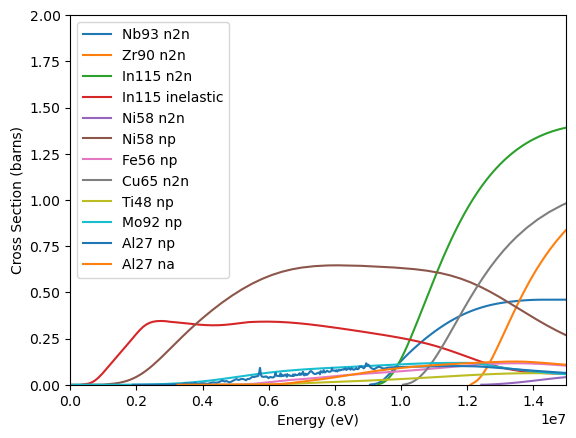

In [9]:
# plot relevant cross sections
from matplotlib import pyplot as plt
from process_irdff import process_irdff
nuclides = {'Nb93':['n2n'], 
            'Zr90':['n2n'], 
            'In115':['n2n', 'inelastic'], 
            'Ni58':['n2n', 'np'],
            'Fe56':['np'], 
            'Cu65':['n2n'], 
            'Ti48':['np'], 
            'Mo92':['np'],
            'Al27':['np', 'na']}
fig, ax = plt.subplots()
for nuclide in nuclides:
    xs_dict = process_irdff(nuclide)
    for reaction in nuclides[nuclide]:
        xs = xs_dict[mt_numbers[nuclide][reaction]]
        ax.plot(xs.x, xs.y, label=f'{nuclide} {reaction}')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Cross Section (barns)')
ax.legend()
ax.set_xlim(0, 1.5e7)
ax.set_ylim(0, 2.0)